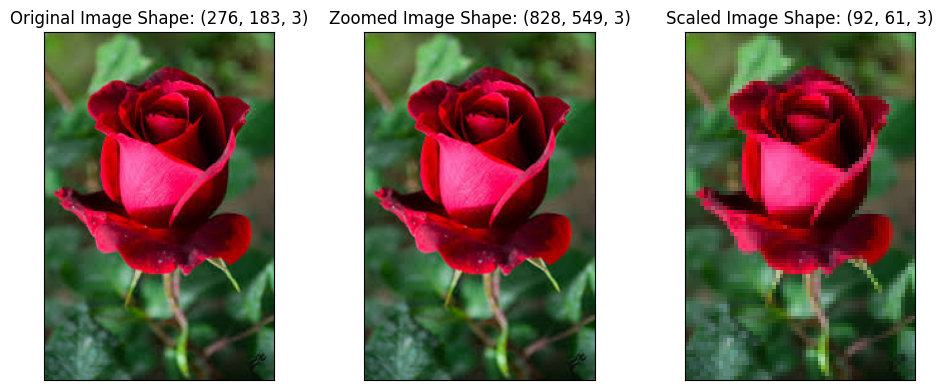

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('Rose.jpg')
if image is None:
    print("Image not found!")
    exit()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

scale_factor_1 = 3.0
scale_factor_2 = 1 / 3.0

height, width = image_rgb.shape[:2]

new_height = int(height * scale_factor_1)
new_width = int(width * scale_factor_1)

zoomed_image = cv2.resize(
    image_rgb,
    (new_width, new_height),
    interpolation=cv2.INTER_CUBIC
)

new_height1 = int(height * scale_factor_2)
new_width1 = int(width * scale_factor_2)

scaled_image = cv2.resize(
    image_rgb,
    (new_width1, new_height1),
    interpolation=cv2.INTER_AREA
)

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

axs[0].imshow(image_rgb)
axs[0].set_title('Original Image Shape: ' + str(image_rgb.shape))

axs[1].imshow(zoomed_image)
axs[1].set_title('Zoomed Image Shape: ' + str(zoomed_image.shape))

axs[2].imshow(scaled_image)
axs[2].set_title('Scaled Image Shape: ' + str(scaled_image.shape))

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

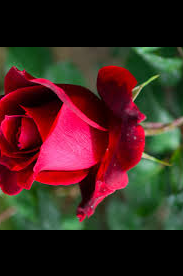

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read image
im = cv2.imread("Rose.jpg")
if im is None:
    print("Image not found!")
    exit()

h, w = im.shape[:2]
ctr = (w // 2, h // 2)

ang = 90
scl = 1.0

mat = cv2.getRotationMatrix2D(ctr, ang, scl)
rot = cv2.warpAffine(im, mat, (w, h))

# Show image in Colab
cv2_imshow(rot)

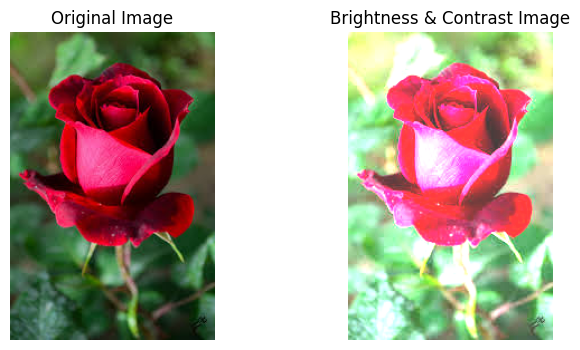

In [3]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("Rose.jpg")
if img is None:
    print("Image not found")
    exit()

# Convert BGR to RGB (important for display)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------- CHANGE VALUES HERE --------
brightness = 60    # Try: -100 to +100
contrast = 2.0     # Try: 0.5 to 3.0
# -----------------------------------

# Apply brightness and contrast
result = cv2.convertScaleAbs(img, alpha=contrast, beta=brightness)

# Display original and result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Brightness & Contrast Image")
plt.axis("off")

plt.show()

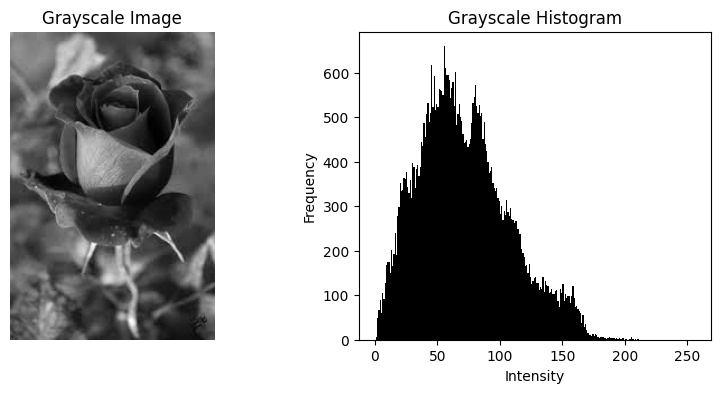

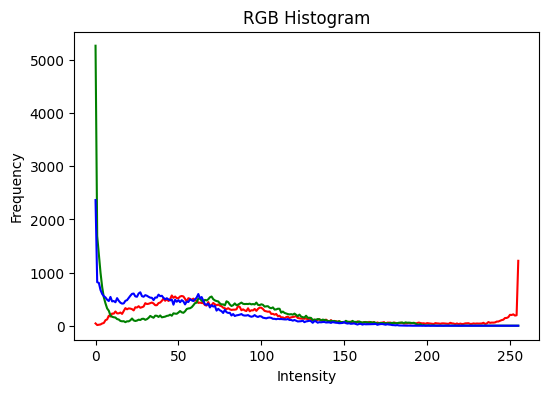

In [5]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("Rose.jpg")
if img is None:
    print("Image not found")
    exit()

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---------- Grayscale Image & Histogram ----------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(gray.ravel(), bins=256, range=[0,256], color='black')
plt.title("Grayscale Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()

# ---------- RGB Histograms ----------
plt.figure(figsize=(6,4))

colors = ('r', 'g', 'b')
for i, c in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0,256])
    plt.plot(hist, color=c)

plt.title("RGB Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()